In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
import xarray as xr

In [41]:
# Crear datos ficticios para div_h y dz
nz = 50
depth = np.linspace(0, 5000, nz)  # profundidad de 0 a 500 m
div_h = 1e-6 * np.sin(np.pi * depth / depth[-1])  # ejemplo de divergencia [1/s]
dz = np.gradient(depth)  # diferencias de profundidad [m]

# Calcular el integrando: -div * dz
integrand = -div_h * dz

# Integrar desde el fondo hacia la superficie usando cumtrapz + flip
w_bottom_up = cumtrapz(integrand[::-1], depth[::-1], initial=0)[::-1]  # [m/s]

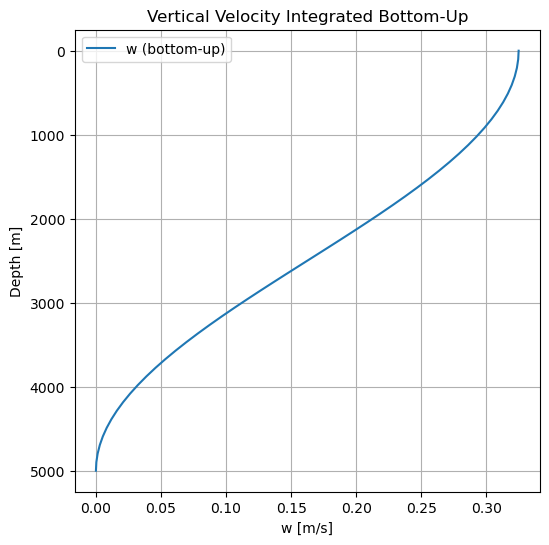

In [5]:
# Graficar resultado
plt.figure(figsize=(6, 6))
plt.plot(w_bottom_up, depth, label='w (bottom-up)')
plt.gca().invert_yaxis()
plt.xlabel('w [m/s]')
plt.ylabel('Depth [m]')
plt.title('Vertical Velocity Integrated Bottom-Up')
plt.grid(True)
plt.legend()
plt.show()

## Real Data

In [9]:
ds = xr.open_dataset(r'../data/amazon2.nc')

In [71]:
A = 6371.0e3  # radio terrestre en metros

# Selecciona los campos de velocidad
u = ds.uo.isel(time=0)
v = ds.vo.isel(time=0)

# --------------------------
# 1. CÁLCULO DE DX, DY, DZ
# --------------------------

dy = np.deg2rad(ds.latitude.shift(latitude=-1) - ds.latitude) * A
dx = (
    np.deg2rad(ds.longitude.shift(longitude=-1) - ds.longitude)
    * A * np.cos(np.deg2rad(ds.latitude))
)

# z_mid y dz entre niveles
z_mid = (ds.depth.shift(depth=-1) + ds.depth) / 2
z_mid = z_mid.isel(depth=slice(0, -1))  # 49 niveles, sin NaN
dz = ds.depth.diff('depth')             # también 49 niveles

# --------------------------
# 2. INTERPOLACIÓN A CENTRO DE CELDA
# --------------------------

# dudx al centro horizontal
dudx = (u.shift(longitude=-1) - u) / dx
dudx = (dudx.shift(latitude=-1) + dudx) / 2.0

# dvdy al centro horizontal
dvdy = (v.shift(latitude=-1) - v) / dy
dvdy = (dvdy.shift(longitude=-1) + dvdy) / 2.0

# lat/lon en el centro
lon_c = (ds.longitude.shift(longitude=-1) + ds.longitude) / 2
lat_c = (ds.latitude.shift(latitude=-1) + ds.latitude) / 2

# Ajustar coordenadas y recortar bordes (porque hicimos shift)
dudx = dudx.assign_coords(longitude=lon_c, latitude=lat_c).isel(longitude=slice(None, -1), latitude=slice(None, -1))
dvdy = dvdy.assign_coords(longitude=lon_c, latitude=lat_c).isel(longitude=slice(None, -1), latitude=slice(None, -1))

# --------------------------
# 3. DIVERGENCIA HORIZONTAL
# --------------------------

div_h = dudx + dvdy
div_h = div_h.transpose("depth", "latitude", "longitude")  # asegurar orden

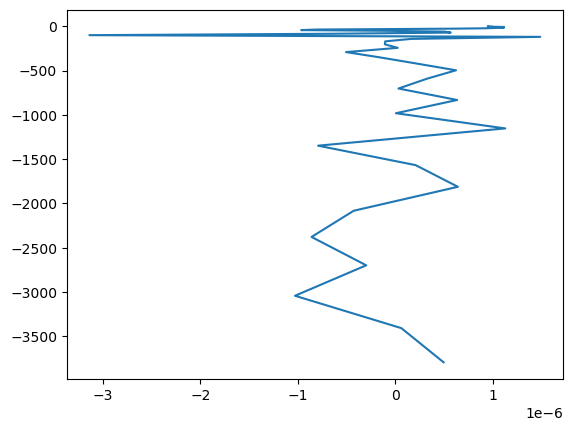

In [25]:
ddiv = div_h[:-1,120,120]
plt.plot(ddiv,-z_mid)

In [82]:
integrand = -ddiv * dz
# Integrar desde el fondo hacia la superficie usando cumtrapz + flip
w_bottom_up = cumtrapz(integrand[::-1], z_mid.isel(depth=slice(0,-1))[::-1], initial=0)[::-1]  # [m/s]

In [95]:
valid = ~np.isnan(integrand) 
integrand_valid = integrand[valid]

In [99]:
valid

<xarray.DataArray (depth: 48)>
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False])
Coordinates:
  * depth      (depth) float32 1.541 2.646 3.819 ... 4.833e+03 5.275e+03
    time       datetime64[ns] 2021-06-01
    latitude   float32 6.375
    longitude  float32 -47.71

In [ ]:
z_valid = z_mid.isel(depth=slice(0, -1))[valid]

w_bottom_up = cumtrapz(integrand_valid[::-1], z_valid[::-1], initial=0)[::-1]

IndexError: dimension coordinate 'depth' conflicts between indexed and indexing objects:
<xarray.DataArray 'depth' (depth: 44)>
array([4.940250e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00, 5.078224e+00,
       6.440614e+00, 7.929560e+00, 9.572997e+00, 1.140500e+01, 1.346714e+01,
       1.581007e+01, 1.849556e+01, 2.159882e+01, 2.521141e+01, 2.944473e+01,
       3.443415e+01, 4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02, 1.558507e+02,
       1.861256e+02, 2.224752e+02, 2.660403e+02, 3.181274e+02, 3.802130e+02,
       4.539377e+02, 5.410889e+02, 6.435668e+02, 7.633331e+02, 9.023393e+02,
       1.062440e+03, 1.245291e+03, 1.452251e+03, 1.684284e+03, 1.941893e+03,
       2.225078e+03, 2.533336e+03, 2.865703e+03, 3.220820e+03], dtype=float32)
Coordinates:
  * depth    (depth) float32 0.494 1.541 2.646 ... 2.533e+03 2.866e+03 3.221e+03
Attributes:
    standard_name:  depth
    long_name:      Depth
    units:         